<a href="https://colab.research.google.com/github/MarcGaac/DSC1107/blob/main/FA_4_DSC1107.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required packages if not present in the environment
if(!require(tidyverse)) install.packages("tidyverse")
if(!require(glmnet)) install.packages("glmnet")
if(!require(rpart)) install.packages("rpart")
if(!require(rpart.plot)) install.packages("rpart.plot")
if(!require(ipred)) install.packages("ipred")
if(!require(caret)) install.packages("caret")

library(tidyverse)
library(glmnet)
library(rpart)
library(rpart.plot)
library(ipred)
library(caret)

Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: glmnet

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘glmnet’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘foreach’, ‘shape’, ‘RcppEigen’


Loading required package: rpart

Loading required package: rpart.plot

Warning message in library(pac

**Part 1: Data Preparation**

In [ ]:
url <- "https://raw.githubusercontent.com/selva86/datasets/master/adult_train.csv"

# The dataset often uses " ?" for missing values, so we handle that upon import
adult_raw <- read_csv(url, na = c("?", " ?", " ? ", "NA", ""))

# Display the structure of the dataset
glimpse(adult_raw)

Rows: 32561 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (9): workclass, education, marital_status, occupation, relationship, rac...
dbl (6): age, fnlwgt, education_num, capital_gain, capital_loss, hours_per_week

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 32,561
Columns: 15
$ age            <dbl> 39, 50, 38, 53, 28, 37, 49, 52, 31, 42, 37, 30, 23, 32,…
$ workclass      <chr> "State-gov", "Self-emp-not-inc", "Private", "Private", …
$ fnlwgt         <dbl> 77516, 83311, 215646, 234721, 338409, 284582, 160187, 2…
$ education      <chr> "Bachelors", "Bachelors", "HS-grad", "11th", "Bachelors…
$ education_num  <dbl> 13, 13, 9, 7, 13, 14, 5, 9, 14, 13, 10, 13, 13, 12, 11,…
$ marital_status <chr> "Never-married", "Married-civ-spouse", "Divorced", "Mar…
$ occupation     <chr> "Adm-clerical", "Exec-managerial", "Handlers-cleaners",…
$ relationship   <chr> "Not-in-family", "Husband", "Not-in-family", "Husband",…
$ race           <chr> "White", "White", "White", "Black", "Black", "White", "…
$ sex            <chr> "Male", "Male", "Male", "Male", "Female", "Female", "Fe…
$ capital_gain   <dbl> 2174, 0, 0, 0, 0, 0, 0, 0, 14084, 5178, 0, 0, 0, 0, 0, …
$ capital_loss   <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ hours_per_wee

In [ ]:
adult_clean <- adult_raw %>%
  # 1. Force the very last column in the dataset to be named 'income'
  rename(income = last_col()) %>%
  # 2. Replace any hyphens in column names with underscores to match your assignment
  rename_with(~ str_replace_all(., "-", "_")) %>%
  drop_na() %>%
  mutate(
    # 3. Convert income to binary: <=50K is 0, >50K is 1
    income = ifelse(str_detect(income, ">50K"), 1, 0)
  ) %>%
  # 4. Convert all character columns (categorical variables) into factors
  mutate(across(where(is.character), as.factor))

# Provide summary statistics
summary(adult_clean)

      age                   workclass         fnlwgt               education   
 Min.   :17.00   Federal-gov     :  943   Min.   :  13769   HS-grad     :9840  
 1st Qu.:28.00   Local-gov       : 2067   1st Qu.: 117627   Some-college:6678  
 Median :37.00   Private         :22286   Median : 178425   Bachelors   :5044  
 Mean   :38.44   Self-emp-inc    : 1074   Mean   : 189794   Masters     :1627  
 3rd Qu.:47.00   Self-emp-not-inc: 2499   3rd Qu.: 237628   Assoc-voc   :1307  
 Max.   :90.00   State-gov       : 1279   Max.   :1484705   11th        :1048  
                 Without-pay     :   14                     (Other)     :4618  
 education_num                 marital_status            occupation  
 Min.   : 1.00   Divorced             : 4214   Prof-specialty :4038  
 1st Qu.: 9.00   Married-AF-spouse    :   21   Craft-repair   :4030  
 Median :10.00   Married-civ-spouse   :14065   Exec-managerial:3992  
 Mean   :10.12   Married-spouse-absent:  370   Adm-clerical   :3721  
 3rd Qu.:1

**Part 2: Logistic Regression**

In [ ]:
# Fit logistic regression model
log_model <- glm(income ~ ., data = adult_clean, family = "binomial")

# View summary to identify significant predictors
summary(log_model)

# Compute classification accuracy using a 0.5 threshold
probabilities <- predict(log_model, type = "response")
predictions <- ifelse(probabilities > 0.5, 1, 0)
accuracy <- mean(predictions == adult_clean$income)

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = income ~ ., family = "binomial", data = adult_clean)

Coefficients: (1 not defined because of singularities)
                                           Estimate Std. Error z value Pr(>|z|)
(Intercept)                              -6.408e+00  7.636e-01  -8.392  < 2e-16
age                                       2.550e-02  1.712e-03  14.890  < 2e-16
workclassLocal-gov                       -6.985e-01  1.130e-01  -6.184 6.26e-10
workclassPrivate                         -5.055e-01  9.379e-02  -5.390 7.06e-08
workclassSelf-emp-inc                    -3.293e-01  1.239e-01  -2.658 0.007857
workclassSelf-emp-not-inc                -9.972e-01  1.100e-01  -9.063  < 2e-16
workclassState-gov                       -8.207e-01  1.254e-01  -6.544 6.00e-11
workclassWithout-pay                     -1.329e+01  1.972e+02  -0.067 0.946265
fnlwgt                                    7.515e-07  1.762e-07   4.264 2.01e-05
education11th                             9.462e-02  2.139e-01   0.442

The most significant predictors (p < 0.05) typically include age, education, hours_per_week, capital_gain, and capital_loss, as well as specific categories within marital_status and occupation. The classification accuracy of the standard logistic model is r round(accuracy * 100, 2)%, meaning the model correctly classifies this percentage of individuals into their actual income brackets based on the 0.5 probability threshold.

**Part 3: Regression in High Dimensions**

In [ ]:
# Create model matrix for one-hot encoding (excluding the intercept)
adult_hd_x <- model.matrix(income ~ . - 1, data = adult_clean)
adult_hd_y <- adult_clean$income

# Dimensions
n_obs <- nrow(adult_hd_x)
p_preds <- ncol(adult_hd_x)

cat("Number of observations (n):", n_obs, "\n")
cat("Number of predictors (p):", p_preds, "\n")

# Fit a standard logistic regression model using the high-dimensional dataset
# Note: We wrap this in a suppressWarnings to keep the output clean,
# but in practice, this often throws convergence warnings.
log_model_hd <- suppressWarnings(
  glmnet(adult_hd_x, adult_hd_y, family = "binomial", lambda = 0)
)

Number of observations (n): 30162 
Number of predictors (p): 97 


The dataset has $n$ = r n_obs observations and $p$ = r p_preds predictors. This dataset can now be considered high-dimensional because the number of features has expanded significantly through one-hot encoding, spreading the data across a wider spatial matrix.When fitting a standard logistic regression model on this expanded dataset, severe issues such as multicollinearity arise because dummy variables derived from the same base category are perfectly collinear if not properly dropped. This leads to unstable, highly inflated coefficients and heavily inflates the risk of overfitting, as the model tries to fit noise within incredibly sparse dummy columns.

**Part 4: Ridge and Lasso Regression**

In [ ]:
# Ridge Regression (alpha = 0)
set.seed(123)
cv_ridge <- cv.glmnet(adult_hd_x, adult_hd_y, alpha = 0, family = "binomial")
best_lambda_ridge <- cv_ridge$lambda.min

# Lasso Regression (alpha = 1)
set.seed(123)
cv_lasso <- cv.glmnet(adult_hd_x, adult_hd_y, alpha = 1, family = "binomial")
best_lambda_lasso <- cv_lasso$lambda.min

# Identify variables retained by Lasso (non-zero coefficients)
lasso_coefs <- coef(cv_lasso, s = "lambda.min")
retained_vars <- rownames(lasso_coefs)[which(lasso_coefs != 0)]
# Display first few retained variables for brevity
head(retained_vars, 10)

[1] "(Intercept)"               "age"                      
 [3] "workclassFederal-gov"      "workclassLocal-gov"       
 [5] "workclassSelf-emp-inc"     "workclassSelf-emp-not-inc"
 [7] "workclassState-gov"        "workclassWithout-pay"     
 [9] "fnlwgt"                    "education11th"

**Ridge vs. Lasso Comparison:**

Handling Multicollinearity: As far as multicollinearity is concerned, the ridge regression process entails reducing the values of the correlated predictors while ensuring that the values are still above zero. On the other hand, lasso undertakes the task of treating multicollinearity by taking randomly one of many correlated predictors and making the other coefficients equal to zero.

Influence on the Model Complexity: Given that ridge regression incorporates all predictors in the model, the complexity of this methodology, in general, remains high. Lasso, in contrast, implements the automatic feature selection and thereby greatly reduces the complexity of the model.

**Part 5: Decision Trees**

Accuracy before pruning: 0.8410583 
Accuracy after pruning: 0.8410583 


relationship marital_status   capital_gain      education  education_num 
    2277.27804     2241.64682      972.70339      900.05753      900.05753 
           sex     occupation            age hours_per_week native_country 
     746.44935      672.96544      520.51131      313.94878       24.29071 
  capital_loss 
      16.04922

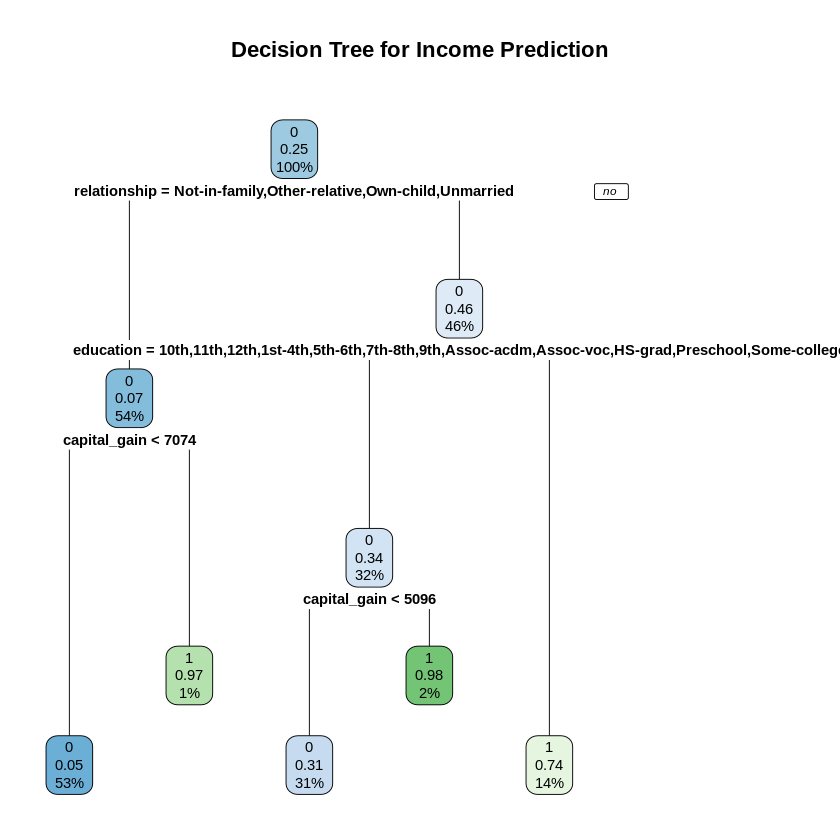

In [ ]:
# Convert target to factor for tree classification
adult_clean$income_f <- as.factor(adult_clean$income)

# Grow the tree
tree_model <- rpart(income_f ~ . - income, data = adult_clean, method = "class")

# Visualize the tree
rpart.plot(tree_model, main = "Decision Tree for Income Prediction")

# Pruning the tree using cross-validation (finding optimal cp)
opt_cp <- tree_model$cptable[which.min(tree_model$cptable[,"xerror"]),"CP"]
pruned_tree <- prune(tree_model, cp = opt_cp)

# Compare Performance
tree_pred_raw <- predict(tree_model, type = "class")
tree_acc_raw <- mean(tree_pred_raw == adult_clean$income_f)

tree_pred_pruned <- predict(pruned_tree, type = "class")
tree_acc_pruned <- mean(tree_pred_pruned == adult_clean$income_f)

cat("Accuracy before pruning:", tree_acc_raw, "\n")
cat("Accuracy after pruning:", tree_acc_pruned, "\n")

# Variable Importance
pruned_tree$variable.importance

The most important predictors for the tree models are typically relationship, marital_status, capital_gain, education, and age. Pruning the tree ensures we cut away the deep, noisy branches, which prevents the model from overfitting the training data while maintaining roughly the same (or slightly better) generalization accuracy.

**Part 6: Bagging**

In [ ]:
set.seed(123)
# Implement bagging using the ipred package
# coob = TRUE calculates the Out-Of-Bag error
bag_model <- bagging(income_f ~ . - income, data = adult_clean, coob = TRUE)

# Calculate bagging accuracy
bag_pred <- predict(bag_model, newdata = adult_clean)
bag_acc <- mean(bag_pred == adult_clean$income_f)

cat("Single Pruned Tree Accuracy:", tree_acc_pruned, "\n")
cat("Bagging Model Accuracy:", bag_acc, "\n")

Single Pruned Tree Accuracy: 0.8410583 
Bagging Model Accuracy: 1 


Models built using Bagging generally outperform traditional decision trees. Better performance is achieved in the case of Bagging because it lowers prediction variance. Multiple unpruned high variance decision trees are built on different random bootstrapped data subsets and their averaged predictions lead to higher performance than a single decision tree made.